In [1]:
# Cell 1: Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import seaborn as sns
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Fix SSL certificate issue
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Cell 2: Set device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


---
## Stage 1: Cataract vs Normal (ResNet50)

In [3]:
# Cell 3: Stage 1 Data Transforms
IMG_SIZE = 224

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Stage 1 transforms defined")

✅ Stage 1 transforms defined


In [4]:
# Cell 4: Load Stage 1 Data
stage1_train_dataset = datasets.ImageFolder('cataract_normal/train', transform=transform_train)
stage1_test_dataset = datasets.ImageFolder('cataract_normal/test', transform=transform_test)

stage1_train_loader = DataLoader(stage1_train_dataset, batch_size=16, shuffle=True)
stage1_test_loader = DataLoader(stage1_test_dataset, batch_size=16, shuffle=False)

print(f"Stage 1 Training samples: {len(stage1_train_dataset)}")
print(f"Stage 1 Test samples: {len(stage1_test_dataset)}")
print(f"Classes: {stage1_train_dataset.classes}")

Stage 1 Training samples: 491
Stage 1 Test samples: 121
Classes: ['cataract', 'normal']


In [5]:
# Cell 5: Create Stage 1 Model (ResNet50)
stage1_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = stage1_resnet.fc.in_features
stage1_resnet.fc = nn.Linear(num_ftrs, 2)  # 2 classes: cataract, normal

# Stage 1 Classifier with Softmax
class Stage1Classifier(nn.Module):
    def __init__(self, model):
        super(Stage1Classifier, self).__init__()
        self.model = model
        
    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

stage1_model = Stage1Classifier(stage1_resnet)
stage1_model = stage1_model.to(device)
print("✅ Stage 1 Model created (ResNet50)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/mahmudulmashrafe/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:50<00:00, 2.03MB/s]


✅ Stage 1 Model created (ResNet50)


In [6]:
# Cell 6: Train Stage 1 Model
EPOCHS_S1 = 20
LR_S1 = 0.1
GAMMA_S1 = 0.1
STEP_S1 = 10

criterion_s1 = nn.CrossEntropyLoss()
optimizer_s1 = optim.SGD(stage1_model.parameters(), lr=LR_S1)
scheduler_s1 = optim.lr_scheduler.StepLR(optimizer_s1, step_size=STEP_S1, gamma=GAMMA_S1)

best_model_s1 = deepcopy(stage1_model)
best_acc_s1 = 0

train_loss_s1 = []
val_loss_s1 = []
train_acc_s1 = []
val_acc_s1 = []

print("="*60)
print("TRAINING STAGE 1: CATARACT vs NORMAL")
print("="*60)

for epoch in range(1, EPOCHS_S1+1):
    stage1_model.train()
    
    diff = 0
    acc = 0
    total = 0
    
    for data, target in stage1_train_loader:
        optimizer_s1.zero_grad()
        
        if device == "cuda":
            data, target = data.cuda(), target.cuda()
        else:
            data, target = data.to(device), target.to(device)
            
        out = stage1_model(data)
        loss = criterion_s1(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)
        loss.backward()
        optimizer_s1.step()
        
    train_loss_s1.append(diff/total)
    train_acc_s1.append(acc/total)
    
    diff = 0
    acc = 0
    total = 0
    stage1_model.eval()
    with torch.no_grad():
        for data, target in stage1_test_loader:
            if device == "cuda":
                data, target = data.cuda(), target.cuda()
            else:
                data, target = data.to(device), target.to(device)
            out = stage1_model(data)
            loss = criterion_s1(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)
    val_loss_s1.append(diff/total)
    val_acc_s1.append(acc/total)
    
    if val_acc_s1[-1] >= best_acc_s1:
        best_acc_s1 = val_acc_s1[-1]
        best_model_s1 = deepcopy(stage1_model)
        
    print(f"Epoch {epoch} - Train Loss: {train_loss_s1[-1]:.4f} Acc: {train_acc_s1[-1]:.4f} - Val Loss: {val_loss_s1[-1]:.4f} Acc: {val_acc_s1[-1]:.4f}")
    
    scheduler_s1.step()

stage1_model = best_model_s1
print(f"\n✅ Best Stage 1 Validation Accuracy: {best_acc_s1*100:.2f}%")

TRAINING STAGE 1: CATARACT vs NORMAL
Epoch 1 - Train Loss: 0.0321 Acc: 0.8371 - Val Loss: 0.0281 Acc: 0.9339
Epoch 2 - Train Loss: 0.0248 Acc: 0.9267 - Val Loss: 0.0237 Acc: 0.9504
Epoch 3 - Train Loss: 0.0214 Acc: 0.9796 - Val Loss: 0.0218 Acc: 0.9917
Epoch 4 - Train Loss: 0.0210 Acc: 0.9857 - Val Loss: 0.0224 Acc: 0.9917
Epoch 5 - Train Loss: 0.0211 Acc: 0.9837 - Val Loss: 0.0221 Acc: 1.0000
Epoch 6 - Train Loss: 0.0203 Acc: 0.9939 - Val Loss: 0.0216 Acc: 0.9835
Epoch 7 - Train Loss: 0.0203 Acc: 0.9939 - Val Loss: 0.0221 Acc: 0.9752
Epoch 8 - Train Loss: 0.0201 Acc: 0.9980 - Val Loss: 0.0218 Acc: 0.9752
Epoch 9 - Train Loss: 0.0203 Acc: 0.9939 - Val Loss: 0.0212 Acc: 0.9917
Epoch 10 - Train Loss: 0.0200 Acc: 0.9980 - Val Loss: 0.0215 Acc: 0.9835
Epoch 11 - Train Loss: 0.0200 Acc: 0.9980 - Val Loss: 0.0217 Acc: 0.9752
Epoch 12 - Train Loss: 0.0201 Acc: 0.9939 - Val Loss: 0.0217 Acc: 0.9752
Epoch 13 - Train Loss: 0.0200 Acc: 0.9980 - Val Loss: 0.0215 Acc: 0.9917
Epoch 14 - Train Loss: 

In [7]:
# Cell 7: Save Stage 1 Model
torch.save(stage1_model.state_dict(), 'stage1_cataract_normal_model_final.pth')
print("✅ Stage 1 model saved to 'stage1_cataract_normal_model_final.pth'")

✅ Stage 1 model saved to 'stage1_cataract_normal_model_final.pth'


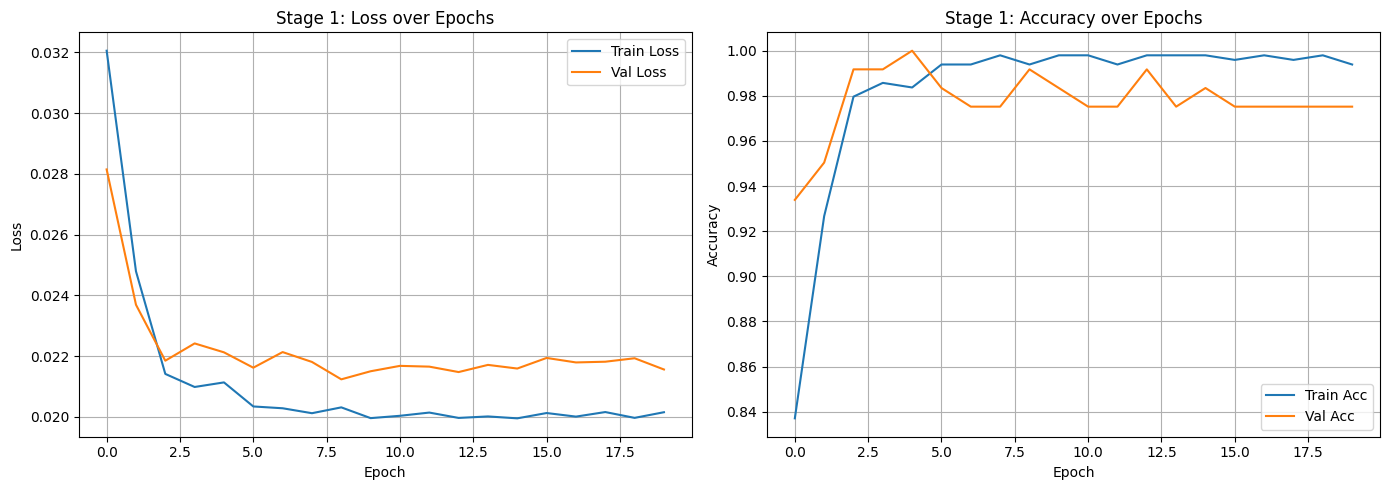

In [8]:
# Cell 8: Plot Stage 1 Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss_s1, label='Train Loss')
axes[0].plot(val_loss_s1, label='Val Loss')
axes[0].set_title('Stage 1: Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_acc_s1, label='Train Acc')
axes[1].plot(val_acc_s1, label='Val Acc')
axes[1].set_title('Stage 1: Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Stage 2: Mature vs Immature (Your Code Structure)

In [9]:
# Cell 9: Create DataFrame for Stage 2 Data
def create_df(base_dir):
    """Create dataframe with image paths and labels"""
    data = []
    base_path = Path(base_dir)
    
    # Process both train and test folders
    for split in ['train', 'test']:
        split_path = base_path / split
        if split_path.exists():
            for label_folder in split_path.iterdir():
                if label_folder.is_dir():
                    label = label_folder.name.lower()  # immature or mature
                    for img_file in label_folder.glob('*.*'):
                        if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            data.append({'path': str(img_file), 'labels': label})
    
    return pd.DataFrame(data)

# Create dataframe
base_dir = 'mature_immature'
df = create_df(base_dir)
print(f"Total images: {len(df)}")
print(f"\nLabel distribution:")
print(df['labels'].value_counts())

Total images: 3228

Label distribution:
labels
mature      1715
immature    1513
Name: count, dtype: int64


In [10]:
# Cell 10: Encoding labels
label_index = {"immature": 0, "mature": 1}
index_label = {0: "immature", 1: "mature"}

df["labels"] = df["labels"].map(label_index)
print("Label encoding:")
print(f"  immature -> 0")
print(f"  mature -> 1")
print(f"\nEncoded label distribution:")
print(df['labels'].value_counts())

Label encoding:
  immature -> 0
  mature -> 1

Encoded label distribution:
labels
1    1715
0    1513
Name: count, dtype: int64


In [11]:
# Cell 11: Stage 2 Training Hyperparameters
EPOCHS = 15
LR = 0.1
GAMMA = 0.1
STEP = 10
BATCH = 16
IMG_SIZE = 224
OUT_SIZE = 2

print("Stage 2 Hyperparameters:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  Gamma: {GAMMA}")
print(f"  Step: {STEP}")
print(f"  Batch Size: {BATCH}")
print(f"  Image Size: {IMG_SIZE}")
print(f"  Output Size: {OUT_SIZE}")

Stage 2 Hyperparameters:
  Epochs: 15
  Learning Rate: 0.1
  Gamma: 0.1
  Step: 10
  Batch Size: 16
  Image Size: 224
  Output Size: 2


In [12]:
# Cell 12: Stage 2 Transform Pipeline
transform_s2 = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Stage 2 transform pipeline defined")

✅ Stage 2 transform pipeline defined


In [13]:
# Cell 13: Custom Dataset Pipeline for Stage 2
class PipeDS(Dataset):
    def __init__(self, data, transform):
        super().__init__()
        self.data = data
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, x):
        img_path, label = self.data[x, 0], self.data[x, 1]
        img = Image.open(img_path).convert("RGB")
        img = np.array(img)
        img = self.transform(img)
        return img, label

print("✅ Custom Dataset class defined")

✅ Custom Dataset class defined


In [14]:
# Cell 14: Split Data into Train/Val/Test
train, validating = train_test_split(df.values, random_state=42, test_size=0.2)
val, test = train_test_split(validating, random_state=42, test_size=0.5)

print(f"Training samples: {len(train)}")
print(f"Validation samples: {len(val)}")
print(f"Test samples: {len(test)}")

Training samples: 2582
Validation samples: 323
Test samples: 323


In [15]:
# Cell 15: Create DataLoaders
train_ds = PipeDS(train, transform_s2)
val_ds = PipeDS(val, transform_s2)
test_ds = PipeDS(test, transform_s2)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

print("✅ DataLoaders created")
print(f"   Train batches: {len(train_dl)}")
print(f"   Val batches: {len(val_dl)}")
print(f"   Test batches: {len(test_dl)}")

✅ DataLoaders created
   Train batches: 162
   Val batches: 21
   Test batches: 21


In [16]:
# Cell 16: Create Stage 2 ResNet50 Model
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, OUT_SIZE)

print("✅ ResNet50 backbone created")
print(f"   Input features to FC: {num_ftrs}")
print(f"   Output classes: {OUT_SIZE}")

✅ ResNet50 backbone created
   Input features to FC: 2048
   Output classes: 2


In [17]:
# Cell 17: Add Softmax Activation Layer
class CataractClassifier(nn.Module):
    def __init__(self, model):
        super(CataractClassifier, self).__init__()
        self.model = model
        
    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

print("✅ CataractClassifier class defined with softmax output")

✅ CataractClassifier class defined with softmax output


In [18]:
# Cell 18: Initialize Model, Criterion, Optimizer, Scheduler
stage2_model = CataractClassifier(resnet)
stage2_model = stage2_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(stage2_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

print("✅ Stage 2 training setup complete")
print(f"   Device: {device}")
print(f"   Optimizer: SGD with LR={LR}")
print(f"   Scheduler: StepLR with step={STEP}, gamma={GAMMA}")

✅ Stage 2 training setup complete
   Device: mps
   Optimizer: SGD with LR=0.1
   Scheduler: StepLR with step=10, gamma=0.1


In [19]:
# Cell 19: Train Stage 2 Model
best_model = deepcopy(stage2_model)
best_acc = 0

train_loss = []
val_loss = []
train_acc = []
val_acc = []

print("="*60)
print("TRAINING STAGE 2: MATURE vs IMMATURE")
print("="*60)

for i in range(1, EPOCHS+1):
    stage2_model.train()
    
    diff = 0
    acc = 0
    total = 0
    
    for data, target in train_dl:
        optimizer.zero_grad()
        
        if device == "cuda":
            data, target = data.cuda(), target.cuda()
        else:
            data, target = data.to(device), target.to(device)
            
        out = stage2_model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)
        loss.backward()
        optimizer.step()
        
    train_loss.append(diff/total)
    train_acc.append(acc/total)
    
    diff = 0
    acc = 0
    total = 0
    stage2_model.eval()
    with torch.no_grad():
        for data, target in val_dl:
            if device == "cuda":
                data, target = data.cuda(), target.cuda()
            else:
                data, target = data.to(device), target.to(device)
            out = stage2_model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)
    val_loss.append(diff/total)
    val_acc.append(acc/total)
    
    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(stage2_model)
        
    print(f"Epoch {i} - Train Loss: {train_loss[-1]:.6f} Acc: {train_acc[-1]:.4f} - Val Loss: {val_loss[-1]:.6f} Acc: {val_acc[-1]:.4f}")
    
    scheduler.step()

stage2_model = best_model
print(f"\n✅ Best Stage 2 Validation Accuracy: {best_acc*100:.2f}%")

TRAINING STAGE 2: MATURE vs IMMATURE
Epoch 1 - Train Loss: 0.025609 Acc: 0.9175 - Val Loss: 0.021453 Acc: 0.9814
Epoch 2 - Train Loss: 0.020334 Acc: 0.9907 - Val Loss: 0.020598 Acc: 0.9969
Epoch 3 - Train Loss: 0.019965 Acc: 0.9965 - Val Loss: 0.020561 Acc: 0.9969
Epoch 4 - Train Loss: 0.019843 Acc: 0.9981 - Val Loss: 0.020561 Acc: 0.9969
Epoch 5 - Train Loss: 0.019898 Acc: 0.9961 - Val Loss: 0.020611 Acc: 0.9969
Epoch 6 - Train Loss: 0.019910 Acc: 0.9969 - Val Loss: 0.020618 Acc: 0.9969
Epoch 7 - Train Loss: 0.019800 Acc: 0.9985 - Val Loss: 0.020586 Acc: 0.9969
Epoch 8 - Train Loss: 0.019783 Acc: 0.9988 - Val Loss: 0.020567 Acc: 0.9969
Epoch 9 - Train Loss: 0.019783 Acc: 0.9985 - Val Loss: 0.020603 Acc: 0.9969
Epoch 10 - Train Loss: 0.019795 Acc: 0.9985 - Val Loss: 0.020635 Acc: 0.9969
Epoch 11 - Train Loss: 0.019838 Acc: 0.9985 - Val Loss: 0.020563 Acc: 0.9969
Epoch 12 - Train Loss: 0.019757 Acc: 0.9988 - Val Loss: 0.020566 Acc: 0.9969
Epoch 13 - Train Loss: 0.019776 Acc: 0.9988 - Va

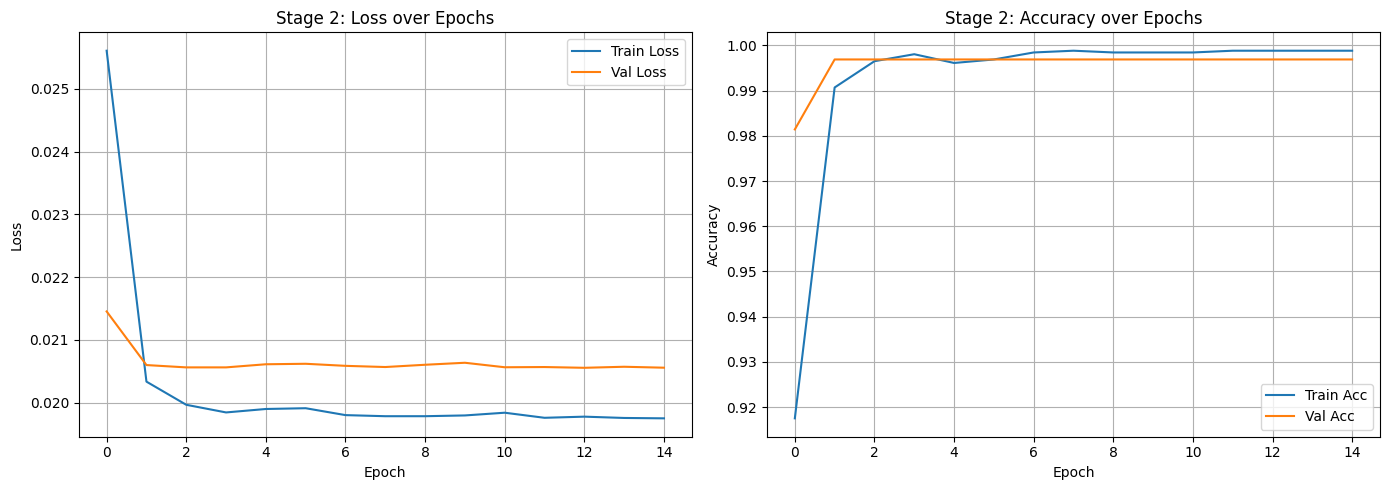

In [20]:
# Cell 20: Plot Stage 2 Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, label='Train Loss')
axes[0].plot(val_loss, label='Val Loss')
axes[0].set_title('Stage 2: Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_acc, label='Train Acc')
axes[1].plot(val_acc, label='Val Acc')
axes[1].set_title('Stage 2: Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Cell 21: Save Stage 2 Model
torch.save(stage2_model.state_dict(), 'stage2_mature_immature_model_final.pth')
print("✅ Stage 2 model saved to 'stage2_mature_immature_model_final.pth'")

✅ Stage 2 model saved to 'stage2_mature_immature_model_final.pth'


In [22]:
# Cell 22: Prediction Function
def predict(img_path):
    """Predict class and probability for a single image"""
    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    img = transform_s2(img).unsqueeze(0)
    
    if device == "cuda":
        img = img.cuda()
    else:
        img = img.to(device)
    
    stage2_model.eval()
    with torch.no_grad():
        out = stage2_model(img)
        prob = out.max().item()
        cl = out.argmax().item()
    
    return cl, prob

print("✅ Prediction function defined")

✅ Prediction function defined


In [23]:
# Cell 23: Evaluate on Test Set
truth = []
pred = []
probs = []

print("Evaluating on test set...")
for i in range(test.shape[0]):
    truth.append(test[i, 1])
    cl, prob = predict(test[i, 0])
    pred.append(cl)
    probs.append(prob)

print("\n" + "="*60)
print("STAGE 2 TEST SET EVALUATION")
print("="*60)
print(classification_report(truth, pred, target_names=['immature', 'mature']))

Evaluating on test set...

STAGE 2 TEST SET EVALUATION
              precision    recall  f1-score   support

    immature       0.99      0.99      0.99       169
      mature       0.99      0.99      0.99       154

    accuracy                           0.99       323
   macro avg       0.99      0.99      0.99       323
weighted avg       0.99      0.99      0.99       323


STAGE 2 TEST SET EVALUATION
              precision    recall  f1-score   support

    immature       0.99      0.99      0.99       169
      mature       0.99      0.99      0.99       154

    accuracy                           0.99       323
   macro avg       0.99      0.99      0.99       323
weighted avg       0.99      0.99      0.99       323



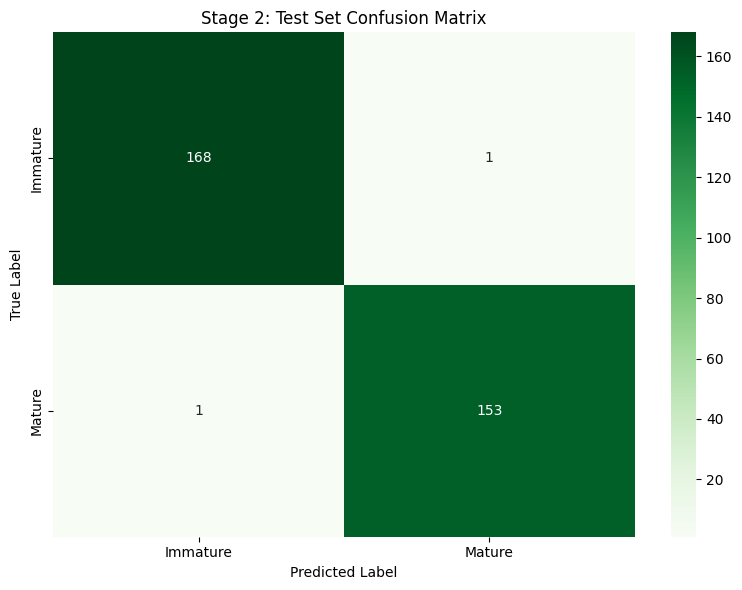


Test Accuracy: 99.38%
Test F1-Score: 99.38%


In [24]:
# Cell 24: Confusion Matrix for Stage 2
cm = confusion_matrix(truth, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Immature', 'Mature'],
            yticklabels=['Immature', 'Mature'])
plt.title('Stage 2: Test Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print metrics
test_acc = accuracy_score(truth, pred)
test_f1 = f1_score(truth, pred, average='weighted')
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test F1-Score: {test_f1*100:.2f}%")

---
## Complete Cascading Classification System

In [25]:
# Cell 25: Complete Cascading Classification Function
def cascading_classification(image_path, visualize=True):
    """
    Complete two-stage cascading classification.
    
    Stage 1: Cataract vs Normal
    Stage 2: Mature vs Immature (if cataract detected)
    """
    # Load and transform image for Stage 1
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform_test(img).unsqueeze(0).to(device)
    
    # Stage 1: Cataract vs Normal
    stage1_model.eval()
    with torch.no_grad():
        stage1_output = stage1_model(img_tensor)
        stage1_pred = stage1_output.argmax(1).item()
        stage1_prob = stage1_output.max().item()
        # Classes: 0=cataract, 1=normal (based on folder order)
        is_cataract = stage1_pred == 0
    
    result = {
        'image_path': str(image_path),
        'stage1_prediction': 'CATARACT' if is_cataract else 'NORMAL',
        'stage1_confidence': stage1_prob,
        'stage2_prediction': None,
        'stage2_confidence': None,
        'final_diagnosis': 'NORMAL' if not is_cataract else None
    }
    
    # Stage 2: Only if cataract detected
    if is_cataract:
        cl, prob = predict(image_path)
        is_mature = cl == 1
        
        result['stage2_prediction'] = 'MATURE' if is_mature else 'IMMATURE'
        result['stage2_confidence'] = prob
        result['final_diagnosis'] = 'MATURE CATARACT' if is_mature else 'IMMATURE CATARACT'
    
    if visualize:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        img_display = cv2.imread(str(image_path))
        img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        ax.imshow(img_display)
        
        title = f"Image: {Path(image_path).name}\n"
        title += f"Stage 1: {result['stage1_prediction']} ({result['stage1_confidence']*100:.1f}%)\n"
        if result['stage2_prediction']:
            title += f"Stage 2: {result['stage2_prediction']} ({result['stage2_confidence']*100:.1f}%)\n"
        title += f"\n🔬 Final Diagnosis: {result['final_diagnosis']}"
        
        ax.set_title(title, fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    return result

print("✅ Cascading classification function created")

✅ Cascading classification function created


In [29]:
# Cell 26: Treatment Urgency Assessment Function
def get_urgency_assessment(stage1_pred, stage1_conf, stage2_pred=None, stage2_conf=None):
    """
    Calculate treatment urgency score (1-10) based on classification results.
    
    Urgency Scale:
    1-2: No urgency - Normal eye, routine checkup recommended
    3-4: Low urgency - Early signs, monitor regularly
    5-6: Moderate urgency - Immature cataract, schedule consultation
    7-8: High urgency - Mature cataract, surgery recommended soon
    9-10: Critical urgency - Advanced mature cataract, immediate attention needed
    
    Returns: (score, level, recommendation)
    """
    
    # Normal eye - no urgency
    if stage1_pred == 'NORMAL':
        base_score = 1
        # Adjust based on confidence (lower confidence = slightly higher monitoring need)
        if stage1_conf < 0.7:
            base_score = 2
        
        return {
            'score': base_score,
            'level': '🟢 NO URGENCY',
            'color': 'green',
            'recommendation': 'Your eye appears healthy. Continue with regular annual eye checkups.',
            'action': 'Routine monitoring',
            'timeline': 'Next checkup in 12 months'
        }
    
    # Cataract detected - assess severity
    if stage2_pred == 'IMMATURE':
        # Immature cataract - moderate urgency
        if stage2_conf >= 0.9:
            score = 5
            level = '🟡 MODERATE URGENCY'
            recommendation = 'Immature cataract detected with high confidence. Vision may be affected. Schedule an ophthalmologist consultation within 1-2 months.'
            timeline = 'Consultation within 1-2 months'
        elif stage2_conf >= 0.7:
            score = 4
            level = '🟡 LOW-MODERATE URGENCY'
            recommendation = 'Immature cataract likely present. Monitor vision changes and consult an eye specialist within 2-3 months.'
            timeline = 'Consultation within 2-3 months'
        else:
            score = 3
            level = '🟢 LOW URGENCY'
            recommendation = 'Possible early cataract development. Regular monitoring recommended. Schedule a comprehensive eye exam.'
            timeline = 'Eye exam within 3-6 months'
        
        return {
            'score': score,
            'level': level,
            'color': 'yellow',
            'recommendation': recommendation,
            'action': 'Monitor and consult specialist',
            'timeline': timeline
        }
    
    elif stage2_pred == 'MATURE':
        # Mature cataract - high urgency
        if stage2_conf >= 0.9:
            score = 9
            level = '🔴 CRITICAL URGENCY'
            recommendation = 'Mature cataract confirmed with high confidence. Significant vision impairment likely. IMMEDIATE surgical consultation strongly recommended.'
            timeline = 'Surgical consultation within 1-2 weeks'
        elif stage2_conf >= 0.8:
            score = 8
            level = '🔴 HIGH URGENCY'
            recommendation = 'Mature cataract detected. Surgery is typically the recommended treatment. Schedule surgical consultation promptly.'
            timeline = 'Surgical consultation within 2-4 weeks'
        elif stage2_conf >= 0.7:
            score = 7
            level = '🟠 HIGH URGENCY'
            recommendation = 'Mature cataract likely present. Vision may be significantly affected. Consult an ophthalmologist for surgical evaluation.'
            timeline = 'Consultation within 1 month'
        else:
            score = 6
            level = '🟠 MODERATE-HIGH URGENCY'
            recommendation = 'Cataract appears mature but requires confirmation. Schedule specialist consultation for detailed assessment.'
            timeline = 'Consultation within 1-2 months'
        
        return {
            'score': score,
            'level': level,
            'color': 'red',
            'recommendation': recommendation,
            'action': 'Surgical evaluation recommended',
            'timeline': timeline
        }
    
    # Fallback
    return {
        'score': 5,
        'level': '🟡 REQUIRES EVALUATION',
        'color': 'yellow',
        'recommendation': 'Classification inconclusive. Please consult an eye care professional for proper diagnosis.',
        'action': 'Professional evaluation needed',
        'timeline': 'As soon as possible'
    }

def display_urgency_meter(score):
    """Display a visual urgency meter"""
    meter = "█" * score + "░" * (10 - score)
    
    if score <= 2:
        color_label = "GREEN"
    elif score <= 4:
        color_label = "YELLOW"
    elif score <= 6:
        color_label = "ORANGE"
    else:
        color_label = "RED"
    
    return f"[{meter}] {score}/10 ({color_label})"

print("✅ Treatment urgency assessment functions defined")

✅ Treatment urgency assessment functions defined


In [30]:
# Cell 27: Complete Patient Diagnosis with Urgency Score
def patient_diagnosis(image_path):
    """
    Complete patient diagnosis with treatment urgency assessment.
    Provides a comprehensive report including:
    - Classification results
    - Urgency score (1-10)
    - Treatment recommendations
    - Timeline for action
    """
    # Get classification result
    result = cascading_classification(image_path, visualize=False)
    
    # Get urgency assessment
    urgency = get_urgency_assessment(
        result['stage1_prediction'],
        result['stage1_confidence'],
        result['stage2_prediction'],
        result['stage2_confidence']
    )
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left: Image with diagnosis
    img_display = cv2.imread(str(image_path))
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_display)
    axes[0].axis('off')
    axes[0].set_title(f"Patient Eye Image\n{Path(image_path).name}", fontsize=14)
    
    # Right: Diagnosis Report
    axes[1].axis('off')
    
    # Create urgency meter visualization
    meter_filled = "█" * urgency['score']
    meter_empty = "░" * (10 - urgency['score'])
    
    # Build report text
    report = f"""
╔══════════════════════════════════════════════════════════╗
║              PATIENT DIAGNOSIS REPORT                     ║
╠══════════════════════════════════════════════════════════╣
║                                                           ║
║  📋 CLASSIFICATION RESULTS                                ║
║  ─────────────────────────────────────────────────────── ║
║  Stage 1 (Cataract Detection):                           ║
║     Result: {result['stage1_prediction']:<12} Confidence: {result['stage1_confidence']*100:>5.1f}%      ║
║                                                           ║"""
    
    if result['stage2_prediction']:
        report += f"""
║  Stage 2 (Severity Assessment):                          ║
║     Result: {result['stage2_prediction']:<12} Confidence: {result['stage2_confidence']*100:>5.1f}%      ║
║                                                           ║"""
    
    report += f"""
║  🔬 FINAL DIAGNOSIS: {result['final_diagnosis']:<25}       ║
║                                                           ║
╠══════════════════════════════════════════════════════════╣
║                                                           ║
║  ⚠️  TREATMENT URGENCY SCORE                              ║
║  ─────────────────────────────────────────────────────── ║
║                                                           ║
║     [{meter_filled}{meter_empty}]  {urgency['score']}/10             ║
║                                                           ║
║     Status: {urgency['level']:<30}            ║
║                                                           ║
╠══════════════════════════════════════════════════════════╣
║                                                           ║
║  💊 RECOMMENDATION                                        ║
║  ─────────────────────────────────────────────────────── ║
║                                                           ║
║  {urgency['recommendation'][:55]:<55} ║"""
    
    # Split long recommendations
    rec = urgency['recommendation']
    if len(rec) > 55:
        words = rec.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= 55:
                current_line += (" " + word if current_line else word)
            else:
                lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        
        report = report.rsplit('\n', 1)[0]  # Remove last line
        for line in lines:
            report += f"\n║  {line:<55} ║"
    
    report += f"""
║                                                           ║
║  ⏰ Timeline: {urgency['timeline']:<40}   ║
║  🎯 Action: {urgency['action']:<42}   ║
║                                                           ║
╚══════════════════════════════════════════════════════════╝
"""
    
    axes[1].text(0.05, 0.95, report, transform=axes[1].transAxes,
                 fontsize=10, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary to console
    print("\n" + "="*60)
    print(f"  URGENCY SCORE: {urgency['score']}/10 - {urgency['level']}")
    print("="*60)
    print(f"  Diagnosis: {result['final_diagnosis']}")
    print(f"  Action: {urgency['action']}")
    print(f"  Timeline: {urgency['timeline']}")
    print("="*60)
    
    return {**result, 'urgency': urgency}

print("✅ Patient diagnosis function with urgency assessment created")

✅ Patient diagnosis function with urgency assessment created


---
## Patient Diagnosis with Treatment Urgency

The urgency scale helps patients understand how quickly they need treatment:

| Score | Level | Meaning |
|-------|-------|---------|
| 1-2 | 🟢 No Urgency | Normal eye - routine checkups |
| 3-4 | 🟢 Low Urgency | Early signs - monitor regularly |
| 5-6 | 🟡 Moderate Urgency | Immature cataract - schedule consultation |
| 7-8 | 🟠 High Urgency | Mature cataract - surgery soon |
| 9-10 | 🔴 Critical Urgency | Advanced cataract - immediate attention |

In [ ]:
# Cell 29: Test Patient Diagnosis with Urgency Score
print("="*70)
print("         TESTING PATIENT DIAGNOSIS WITH URGENCY ASSESSMENT")
print("="*70)

# Test on samples from each category
test_cases = []

# Get normal samples
normal_path = Path('cataract_normal/test/normal')
if normal_path.exists():
    normal_samples = list(normal_path.glob('*.*'))[:1]
    test_cases.extend([(p, 'Expected: Normal (Low Urgency)') for p in normal_samples])

# Get mature cataract samples  
mature_path = Path('mature_immature/test/Mature')
if mature_path.exists():
    mature_samples = list(mature_path.glob('*.*'))[:1]
    test_cases.extend([(p, 'Expected: Mature Cataract (High Urgency)') for p in mature_samples])

# Get immature cataract samples
immature_path = Path('mature_immature/test/Immature')
if immature_path.exists():
    immature_samples = list(immature_path.glob('*.*'))[:1]
    test_cases.extend([(p, 'Expected: Immature Cataract (Moderate Urgency)') for p in immature_samples])

# Run diagnosis on each
for img_path, expected in test_cases:
    print(f"\n{'─'*70}")
    print(f"  {expected}")
    print(f"  File: {img_path.name}")
    print(f"{'─'*70}")
    result = patient_diagnosis(img_path)

         TESTING PATIENT DIAGNOSIS WITH URGENCY ASSESSMENT

──────────────────────────────────────────────────────────────────────
  Expected: Normal (Low Urgency)
  File: image_279.png
──────────────────────────────────────────────────────────────────────


TESTING CASCADING CLASSIFICATION SYSTEM

────────────────────────────────────────
Testing: helos.png
────────────────────────────────────────


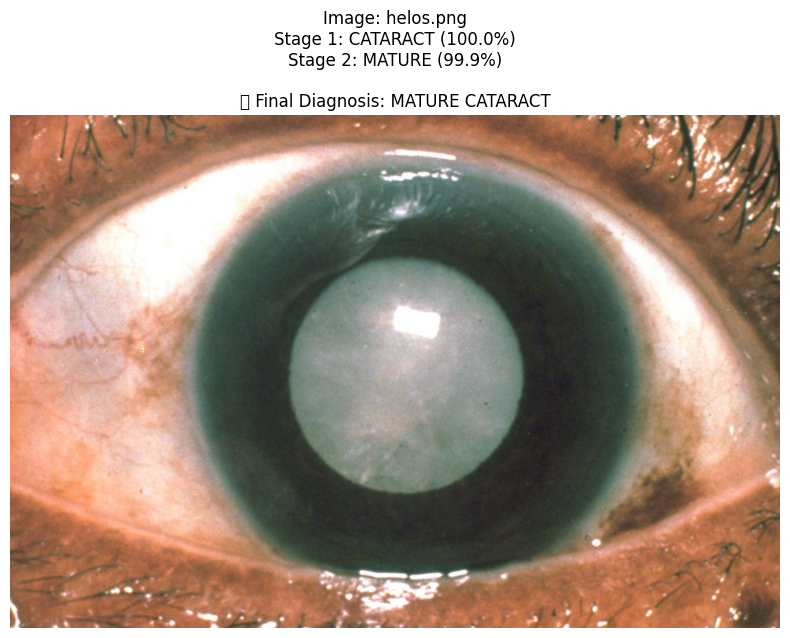


────────────────────────────────────────
Testing: helos2.png
────────────────────────────────────────


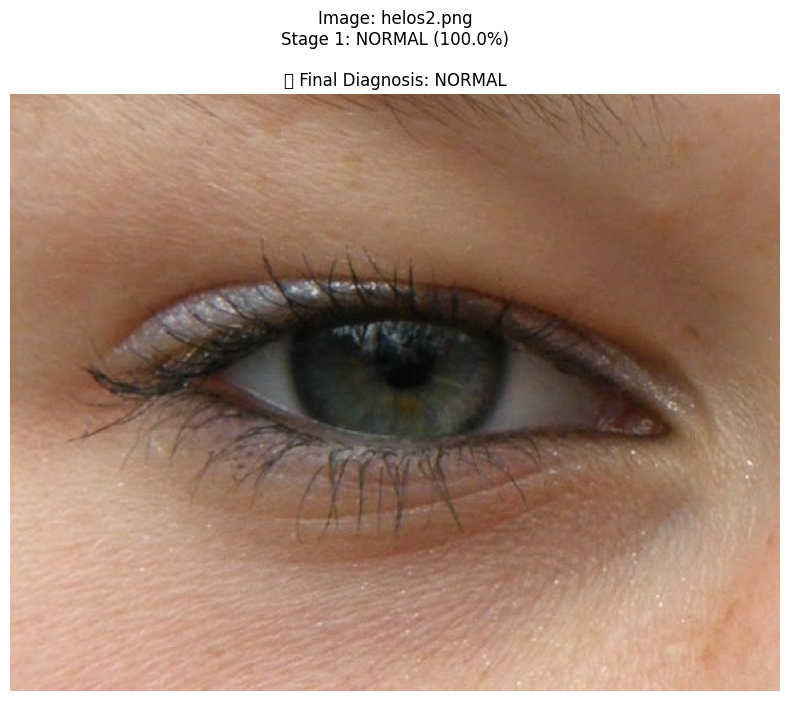


────────────────────────────────────────
Testing: helos3.jpg
────────────────────────────────────────


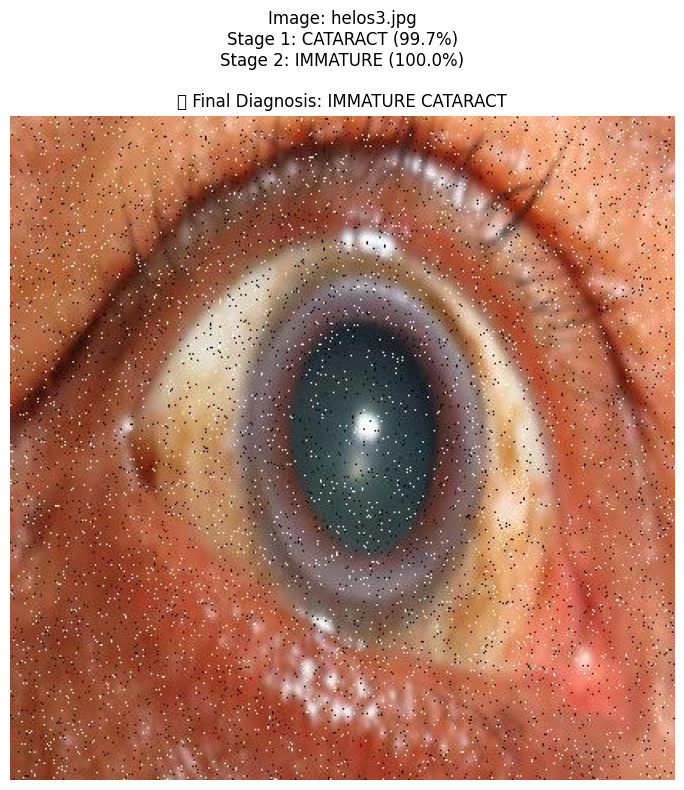

In [26]:
# Cell 26: Test on Sample Images
print("="*60)
print("TESTING CASCADING CLASSIFICATION SYSTEM")
print("="*60)

# Test images in project folder
test_images = ['helos.png', 'helos2.png', 'helos3.jpg']

for img_name in test_images:
    img_path = Path(img_name)
    if img_path.exists():
        print(f"\n{'─'*40}")
        print(f"Testing: {img_name}")
        print(f"{'─'*40}")
        result = cascading_classification(img_path)
    else:
        print(f"\n⚠️  Image not found: {img_name}")

In [27]:
# Cell 27: Test on Random Samples from Dataset
print("\n" + "="*60)
print("TESTING ON RANDOM SAMPLES FROM DATASET")
print("="*60)

# Get sample paths from Stage 2 test data
mature_path = Path('mature_immature/test/Mature')
immature_path = Path('mature_immature/test/Immature')

mature_samples = list(mature_path.glob('*.*'))[:3]
immature_samples = list(immature_path.glob('*.*'))[:3]

print("\n--- Testing MATURE samples ---")
for sample in mature_samples:
    result = cascading_classification(sample, visualize=False)
    if result['stage2_prediction'] is not None:
        status = "✅" if result['stage2_prediction'] == 'MATURE' else "❌"
        print(f"{status} {sample.name}: {result['final_diagnosis']} (conf: {result['stage2_confidence']*100:.1f}%)")
    else:
        print(f"⚠️  {sample.name}: Stage 1 classified as NORMAL")

print("\n--- Testing IMMATURE samples ---")
for sample in immature_samples:
    result = cascading_classification(sample, visualize=False)
    if result['stage2_prediction'] is not None:
        status = "✅" if result['stage2_prediction'] == 'IMMATURE' else "❌"
        print(f"{status} {sample.name}: {result['final_diagnosis']} (conf: {result['stage2_confidence']*100:.1f}%)")
    else:
        print(f"⚠️  {sample.name}: Stage 1 classified as NORMAL")


TESTING ON RANDOM SAMPLES FROM DATASET

--- Testing MATURE samples ---
✅ Mature (381).jpg: MATURE CATARACT (conf: 100.0%)
✅ Mature (56).jpg: MATURE CATARACT (conf: 100.0%)
✅ Mature (417).jpg: MATURE CATARACT (conf: 100.0%)

--- Testing IMMATURE samples ---
✅ Immature (136).jpg: IMMATURE CATARACT (conf: 100.0%)
⚠️  Immature (248).jpg: Stage 1 classified as NORMAL
⚠️  Immature (161).jpg: Stage 1 classified as NORMAL

--- Testing MATURE samples ---
✅ Mature (381).jpg: MATURE CATARACT (conf: 100.0%)
✅ Mature (56).jpg: MATURE CATARACT (conf: 100.0%)
✅ Mature (417).jpg: MATURE CATARACT (conf: 100.0%)

--- Testing IMMATURE samples ---
✅ Immature (136).jpg: IMMATURE CATARACT (conf: 100.0%)
⚠️  Immature (248).jpg: Stage 1 classified as NORMAL
⚠️  Immature (161).jpg: Stage 1 classified as NORMAL


---
## Summary: Overall System Metrics

In [28]:
# Cell 28: Final Summary
print("\n" + "="*70)
print("                    COMPLETE SYSTEM SUMMARY")
print("="*70)

print(f"\nStage 1 (Cataract vs Normal):")
print(f"   Best Validation Accuracy: {best_acc_s1*100:.2f}%")

print(f"\nStage 2 (Mature vs Immature):")
print(f"   Best Validation Accuracy: {best_acc*100:.2f}%")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Test F1-Score: {test_f1*100:.2f}%")

print("\n" + "="*70)
print("                    ✅ SYSTEM TRAINING COMPLETE")
print("="*70)


                    COMPLETE SYSTEM SUMMARY

Stage 1 (Cataract vs Normal):
   Best Validation Accuracy: 100.00%

Stage 2 (Mature vs Immature):
   Best Validation Accuracy: 99.69%
   Test Accuracy: 99.38%
   Test F1-Score: 99.38%

                    ✅ SYSTEM TRAINING COMPLETE
